<a href="https://colab.research.google.com/github/JulietaC1/JulietaC1/blob/main/Pr%C3%A1ctica_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Explicación del Proyecto:**

Este proyecto consiste en un análisis integral del catálogo de contenidos de Netflix hasta el año 2025. A diferencia de los análisis estándar que solo miran géneros y fechas, este dataset permite cruzar la oferta de contenido (qué tipo de películas produce Netflix) con el éxito comercial y la recepción del público (popularidad y rentabilidad).

El valor añadido de este trabajo es la capacidad de identificar si la estrategia de inversión de Netflix (Budget) se alinea con lo que realmente genera ingresos (Revenue) y lo que los usuarios prefieren ver (Popularity / Vote Average).

**Objetivo del Trabajo:**


*  Objetivo General: Analizar la relación entre la inversión económica, el género y la popularidad de las producciones en Netflix para determinar qué factores impulsan el éxito comercial y la satisfacción del usuario en 2025.



*   Objetivos Específicos (Técnicos)Análisis de Rentabilidad (ROI): Calcular el retorno de inversión mediante la fórmula $ROI = \frac{Revenue - Budget}{Budget}$ para identificar qué géneros y directores son los más rentables.

*  Segmentación de Audiencia: Clasificar las películas según su rating (edad) y language para entender a qué mercados geográficos está apuntando Netflix con sus lanzamientos más costosos.

* Análisis de Tendencias Temporales: Evaluar la evolución
del contenido añadido (date_added) frente al año de estreno (release_year) para medir la velocidad de adquisición de contenido original vs. licencias.
* Predicción de Popularidad (Machine Learning): Crear un modelo que intente predecir la popularity o el vote_average de una película basándose en variables como el presupuesto, el género y el país de origen.

Primeras Pruebas: Entrega 1_**Llanes**

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
ruta = "/content/drive/MyDrive/DATA SCIENCE/netflix_movies_detailed_up_to_2025.csv"

In [14]:
import pandas as pd

In [17]:
ruta = "/content/drive/MyDrive/DATA SCIENCE/netflix_movies_detailed_up_to_2025.csv"

df = pd.read_csv(
    ruta,
    sep=';',
    engine='python',
    index_col=False,
    encoding='latin-1'
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16034 entries, 0 to 16033
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16034 non-null  object 
 1   type          16022 non-null  object 
 2   title         16021 non-null  object 
 3   director      15885 non-null  object 
 4   cast          15811 non-null  object 
 5   country       15549 non-null  object 
 6   date_added    16009 non-null  object 
 7   release_year  16004 non-null  object 
 8   rating        16001 non-null  object 
 9   genres        15892 non-null  object 
 10  language      15999 non-null  object 
 11  description   15865 non-null  object 
 12  popularity    15729 non-null  object 
 13  vote_count    15728 non-null  float64
 14  vote_average  15728 non-null  float64
 15  budget        15728 non-null  float64
 16  revenue       15728 non-null  float64
dtypes: float64(4), object(13)
memory usage: 2.1+ MB


In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'genres', 'language', 'description',
       'popularity', 'vote_count', 'vote_average', 'budget', 'revenue'],
      dtype='object')

In [ ]:
list(df.columns)

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'genres',
 'language',
 'description',
 'popularity',
 'vote_count',
 'vote_average',
 'budget',
 'revenue']

In [ ]:
# Convertir columnas a numéricas
df["release_year"] = pd.to_numeric(df["release_year"], errors="coerce")
df["popularity"] = pd.to_numeric(df["popularity"], errors="coerce")

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16034 entries, 0 to 16033
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16034 non-null  object 
 1   type          16022 non-null  object 
 2   title         16021 non-null  object 
 3   director      15885 non-null  object 
 4   cast          15811 non-null  object 
 5   country       15549 non-null  object 
 6   date_added    16009 non-null  object 
 7   release_year  16002 non-null  float64
 8   rating        16001 non-null  object 
 9   genres        15892 non-null  object 
 10  language      15999 non-null  object 
 11  description   15865 non-null  object 
 12  popularity    15719 non-null  float64
 13  vote_count    15728 non-null  float64
 14  vote_average  15728 non-null  float64
 15  budget        15728 non-null  float64
 16  revenue       15728 non-null  float64
dtypes: float64(6), object(11)
memory usage: 2.1+ MB


In [ ]:
df.isnull().sum()

,0
show_id,0
type,12
title,13
director,149
cast,223
country,485
date_added,25
release_year,32
rating,33
genres,142


**Estructura del DataSet seleccionado:**
- 16.043 FILAS
- 17 COLUMNAS
- 13 COLUMNAS TIPO OBJECT
- 4 COLUMNAS NUMERICAS (FLOAT)

**Columnas númericas:**
- vote_count
- vote_average
- budget
- revenue




# **Primeros Análisis:**

In [ ]:
df["type"].value_counts()


,count
type,
Movie,16000
sous la neige,1
"nâest-il pas permis de croire aux contes de fÃ©es ?""",1
"Yoo Gun becomes involved in a case which changes his fate forever.""",1
31.91,1
16.473,1
they start getting tired of each other. The wife attends her husband's superior's house warming party one day. The superior is sending her signals and the jealous husband lights up his passionate love for his wife once again...,1
12.728,1
Bamberski attempts to take the trial to France,1


In [ ]:
df["release_year"].value_counts().head(10)


,count
release_year,
2010.0,1000
2011.0,1000
2012.0,1000
2014.0,1000
2015.0,1000
2016.0,1000
2024.0,1000
2017.0,1000
2018.0,1000


In [ ]:
genres_series = df["genres"].dropna().str.split(";").explode()
genres_series.value_counts().head(10)


,count
genres,
Drama,1336
Comedy,776
Documentary,587
"Drama, Romance",473
Horror,391
"Comedy, Drama",389
"Horror, Thriller",356
"Comedy, Romance",242
Romance,232


In [ ]:
df[df["vote_count"] > 100] \
    .sort_values("vote_average", ascending=False)[["title", "vote_average", "vote_count"]] \
    .head(10)


,title,vote_average,vote_count
14795,Succubus,9.500,157.0
7114,Nude,9.500,161.0
13422,Kill Shot,9.300,158.0
10905,Break the Silence: The Movie,9.000,183.0
10628,The Three Deaths of Marisela Escobedo,8.900,228.0
12814,BTS: Permission to Dance on Stage - LA,8.900,157.0
12090,Selena Gomez: My Mind & Me,8.700,451.0
13326,Â¿Quieres ser mi hijo?,8.599,282.0
9765,Everybodyâs Everything,8.548,282.0
9026,Parasite,8.500,18728.0


In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cols_numericas = ["popularity", "vote_count", "vote_average", "budget", "revenue", "release_year"]
for col in cols_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[cols_numericas].isnull().sum()

,0
popularity,315
vote_count,306
vote_average,306
budget,306
revenue,306
release_year,32


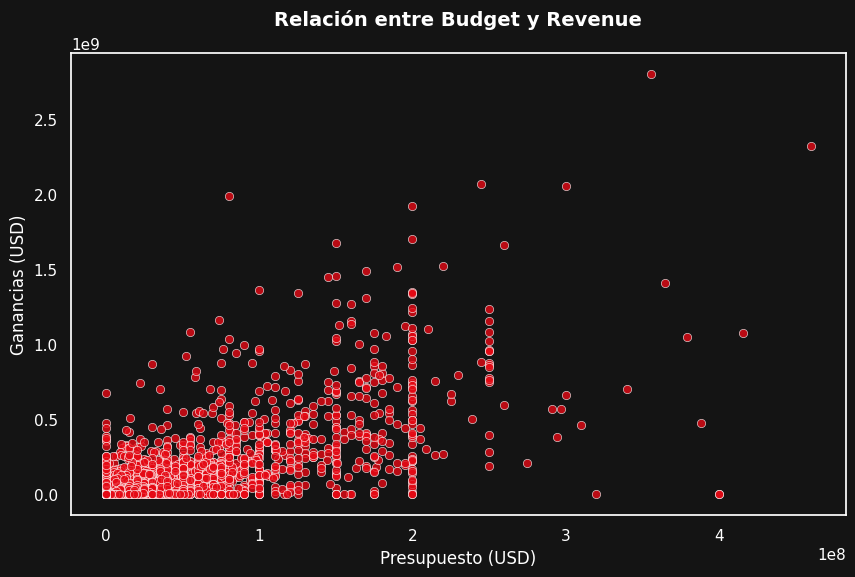

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

NETFLIX_RED = "#E50914"
NETFLIX_DARK = "#141414"


sns.set_theme(style="dark", rc={
    "axes.facecolor": NETFLIX_DARK,
    "figure.facecolor": NETFLIX_DARK,
    "grid.color": "#222222",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})


plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="budget",
    y="revenue",
    color=NETFLIX_RED,
    edgecolor="white",
    alpha=0.8
)


plt.title("Relación entre Budget y Revenue", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Presupuesto (USD)")
plt.ylabel("Ganancias (USD)")

plt.show()


# **Interpretación técnica:**

El scatterplot analiza la relación entre el presupuesto (BUDGET) y los ingresos generados (REVENUE).

Este gráfico permite evaluar:


* Existencia de correlación positiva o negativa.

* Concentración de producciones en determinados rangos de inversión.


Presencia de outliers (producciones con alto presupuesto pero bajo revenue o viceversa).

Si se observa una tendencia ascendente clara, sugiere que un mayor presupuesto podría estar asociado con mayores ingresos.
Sin embargo, una dispersión amplia indicaría que el presupuesto no garantiza necesariamente éxito financiero.

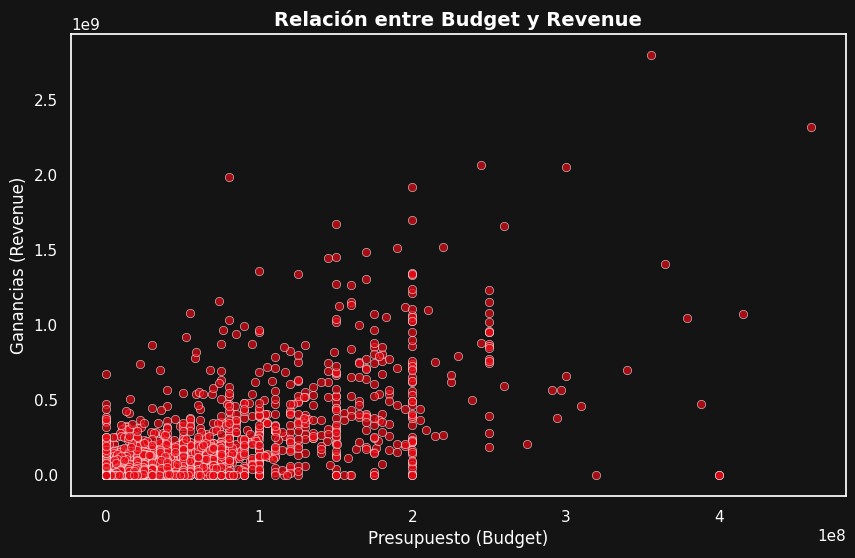

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

NETFLIX_RED = "#E50914"
NETFLIX_DARK = "#141414"

sns.set_style("dark", {"axes.facecolor": NETFLIX_DARK, "figure.facecolor": NETFLIX_DARK})

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="budget", y="revenue", color=NETFLIX_RED, edgecolor="white", alpha=0.7)

plt.title("Relación entre Budget y Revenue", color="white", fontsize=14, fontweight='bold')
plt.xlabel("Presupuesto (Budget)", color="white")
plt.ylabel("Ganancias (Revenue)", color="white")

plt.tick_params(colors='white')

plt.show()

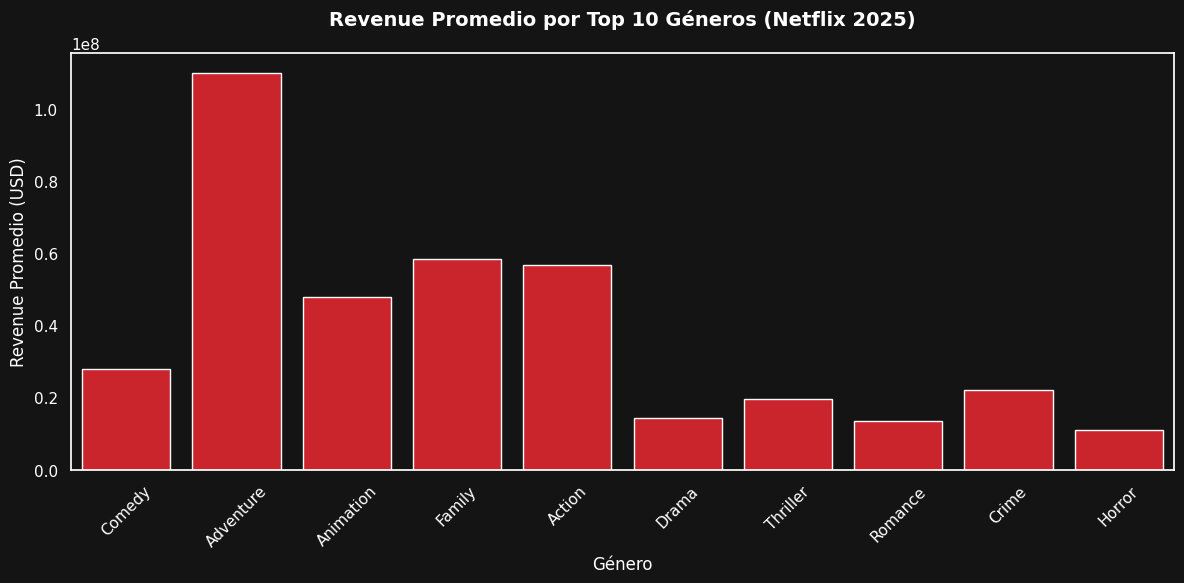

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

NETFLIX_RED = "#E50914"
NETFLIX_DARK = "#141414"

sns.set_theme(style="dark", rc={
    "axes.facecolor": NETFLIX_DARK,
    "figure.facecolor": NETFLIX_DARK,
    "grid.color": "#222222",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

top_genres = (
    df["genres"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
    .index
)

df_genres = df.assign(GENRE=df["genres"].str.split(", ")).explode("GENRE").reset_index(drop=True)
df_top = df_genres[df_genres["GENRE"].isin(top_genres)]

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_top,
    x="GENRE",
    y="revenue",
    estimator="mean",
    color=NETFLIX_RED,
    errorbar=None
) # Agregado el paréntesis de cierre aquí

plt.xticks(rotation=45)
plt.title("Revenue Promedio por Top 10 Géneros (Netflix 2025)", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Género", fontsize=12)
plt.ylabel("Revenue Promedio (USD)", fontsize=12)

plt.tight_layout()

plt.show()

# **Interpretación técnica:**


El barplot muestra el ingreso promedio (REVENUE) de los géneros más frecuentes dentro del dataset.

Este análisis permite:


*   Identificar qué géneros son más rentables en promedio.
*   Detectar posibles preferencias del mercado.
*   Comparar desempeño financiero entre categorías.



Es importante considerar que el promedio puede verse afectado por valores extremos, por lo que se recomienda complementar este análisis con medidas de dispersión.

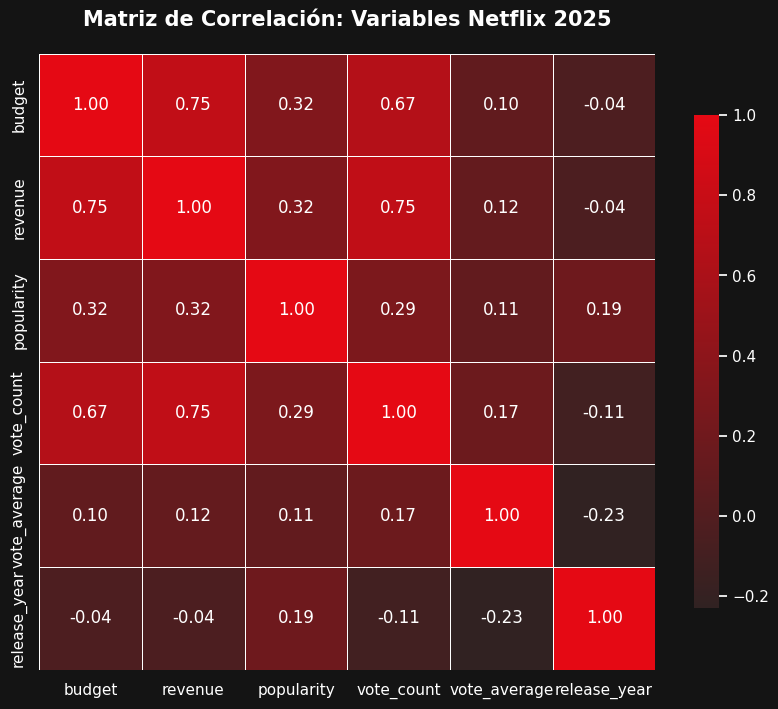

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definir la paleta de colores "Netflix"
NETFLIX_RED = "#E50914"
NETFLIX_DARK = "#141414"

# 2. Configurar el estilo oscuro global
sns.set_theme(style="dark", rc={
    "axes.facecolor": NETFLIX_DARK,
    "figure.facecolor": NETFLIX_DARK,
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

# 3. Seleccionar columnas numéricas y calcular correlación
# Agregamos las financieras y las de popularidad
cols_interes = ['budget', 'revenue', 'popularity', 'vote_count', 'vote_average', 'release_year']
corr_matrix = df[cols_interes].corr()

# 4. Crear el mapa de calor (Heatmap)
plt.figure(figsize=(10, 8))

# Creamos un mapa de colores personalizado de Negro a Rojo
cmap_netflix = sns.dark_palette(NETFLIX_RED, as_cmap=True)

sns.heatmap(
    corr_matrix,
    annot=True,          # Muestra los números dentro de los cuadros
    fmt=".2f",           # Dos decimales
    cmap=cmap_netflix,   # Nuestra paleta personalizada
    linewidths=0.5,      # Línea sutil entre cuadros
    square=True,         # Cuadros perfectamente simétricos
    cbar_kws={"shrink": .8}
)

plt.title("Matriz de Correlación: Variables Netflix 2025", fontsize=15, fontweight='bold', pad=20)
plt.show()

Se realizó un análisis de correlación de Pearson para identificar los motores de éxito en el catálogo 2025. Los resultados indican que mientras el Budget tiene una relación directa con el Revenue, su impacto en la **Calificación de los Usuarios** (*Vote Average*) es marginal, sugiriendo que la calidad narrativa es independiente de la inversión financiera.

In [47]:
top_5_revenue = df.sort_values(by='revenue', ascending=False).head(5)
display(top_5_revenue[['title', 'revenue']])

,title,revenue
9025,Avengers: Endgame,2.799439e+09
12036,Avatar: The Way of Water,2.320250e+09
5013,Star Wars: The Force Awakens,2.068224e+09
8021,Avengers: Infinity War,2.052415e+09
15052,Ne Zha 2,1.990000e+09


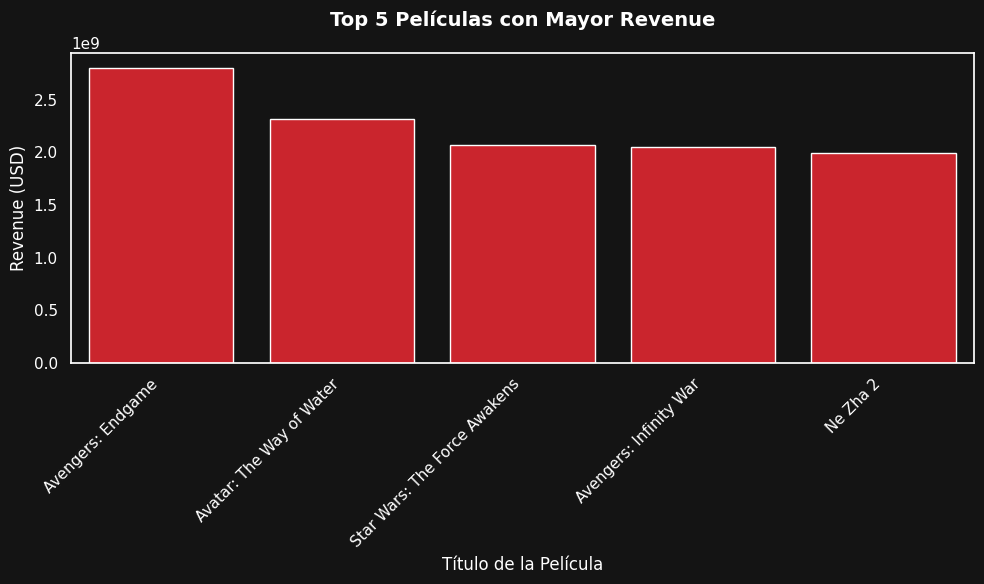

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

NETFLIX_RED = "#E50914"
NETFLIX_DARK = "#141414"

sns.set_theme(style="dark", rc={
    "axes.facecolor": NETFLIX_DARK,
    "figure.facecolor": NETFLIX_DARK,
    "grid.color": "#222222",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

plt.figure(figsize=(10, 6))
sns.barplot(x='title', y='revenue', data=top_5_revenue, color=NETFLIX_RED)
plt.title('Top 5 Películas con Mayor Revenue', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Título de la Película', fontsize=12)
plt.ylabel('Revenue (USD)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

El análisis exploratorio evidencia patrones claros entre inversión, popularidad y desempeño financiero. Las relaciones identificadas sirven como base para futuras etapas de modelado predictivo o segmentación de contenido.